# Learning Objectives

- Implement ReAct agents using `langchain` abstractions

# Setup

In [1]:
!pip install openai \
                langchain==0.1.9 \
                langchain-openai==0.0.8 \
                langchain-experimental==0.0.52 \
                langchainhub==0.1.15 \
                google-search-results \
                langchain-community


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install -U scikit-learn


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import json

import pandas as pd

from langchain import hub

from langchain_openai import ChatOpenAI

from langchain.agents.agent_types import AgentType
from langchain.agents import Tool, AgentExecutor, create_react_agent

from langchain_experimental.agents.agent_toolkits import create_pandas_dataframe_agent
from langchain_experimental.utilities import PythonREPL
from langchain.tools import DuckDuckGoSearchRun, yahoo_finance_news
from langchain_community.utilities import GoogleSerperAPIWrapper
import os
from sklearn.datasets import fetch_openml

c:\Users\sayan\Downloads\vitesco\virtual_environment\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.7.0) or chardet (7.6.0)/charset_normalizer (3.5.1) doesn't match a supported version!
  warnings.warn(


In [2]:
openai_api_key = os.getenv("OPENAI_API_KEY")
serper_api_key = os.getenv('SERPER_API_KEY')

In [3]:
gpt4 = ChatOpenAI(
    model='gpt-4',
    api_key=openai_api_key,
    temperature=0
)

# `LangChain` implements ReAct

 ## Overview

One popular implementation of the ReAct framework is in the `langchain` package that offers several abstractions for different parts of the ReAct paradigm. LangChain also provides out-of-the box solutions to common problems solved by LLM Agents (e.g., Retrieval-Augmented Generation).

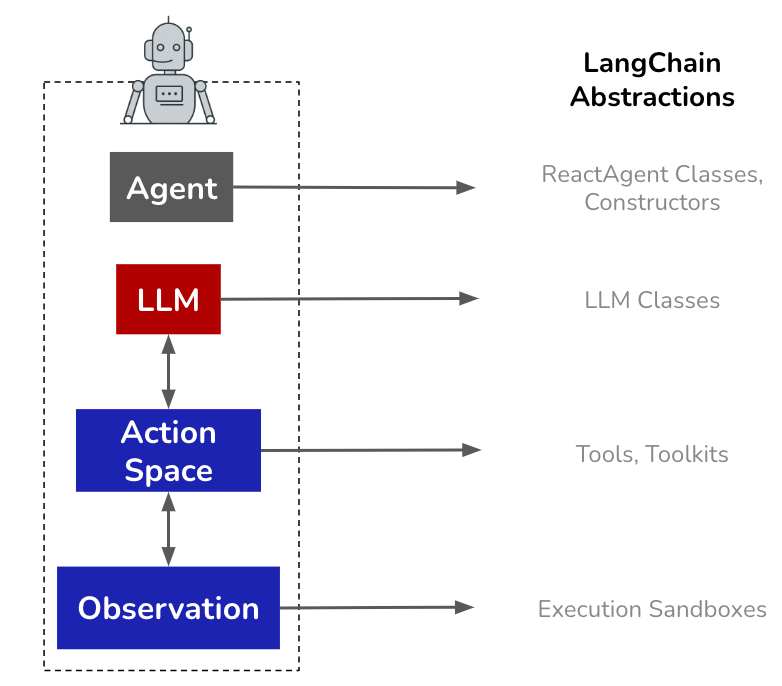

## Tools

An important abstraction that allows `langchain` agents to *act* are `Tool` classes. Each tool allows the agent to execute a specific action as a chain. Let us look at two such tools - `PythonREPL` & `DuckDuckGoSearchRun`.   

In [4]:
python_repl = PythonREPL()

In [5]:
python_repl.run("print('Hello World! I am a langchain tool that allows running arbitrary Python code')")

Python REPL can execute arbitrary code. Use with caution.


'Hello World! I am a langchain tool that allows running arbitrary Python code\n'

In [6]:
python_repl.schema()

{'title': 'PythonREPL',
 'description': 'Simulates a standalone Python REPL.',
 'type': 'object',
 'properties': {'_globals': {'title': ' Globals', 'type': 'object'},
  '_locals': {'title': ' Locals', 'type': 'object'}}}

We can wrap this REPL as a tool that can be used by an agent like so:

In [7]:
repl_tool = Tool(
    name="python_repl",
    description="A Python shell used to execute python commands. Input should be a valid python command.",
    func=python_repl.run,
)

We can now invoke this tool (just as an agent would do).

In [8]:
repl_tool.invoke('print("Hello World!")')

'Hello World!\n'

In [9]:
serper_search = GoogleSerperAPIWrapper(serper_api_key=serper_api_key)

In [10]:
serper_search.run("Who is the founder of Tesla?")

"The company was incorporated in July 2003 by Martin Eberhard and Marc Tarpenning as Tesla Motors. Its name is a tribute to the inventor and electrical engineer ... Tesla was incorporated in July 2003 by Martin Eberhard and Marc Tarpenning as Tesla Motors. Tesla Motors was founded as an electric carmaker by engineers Martin Eberhard and Marc Tarpenning in 2003. Elon Musk co-founded and leads Tesla, SpaceX, Neuralink and The Boring Company. As the co-founder and CEO of Tesla, Elon leads all product design, ... co-founder, Marc Tarpenning '85, his co-founder Martin Eberhard and Tesla CEO Elon Musk. They incorporated Tesla Motors in April 2003. have left Tesla in the ... founded in San Carlos, California in 2003 by American entrepreneurs Martin Eberhard and Marc Tarpenning. The company is named after Serbian-American inventor ... Contrary to popular belief, Elon Musk did not start Tesla. He certainly made it his own over the years, investing early on and then overseeing ..."

In [11]:
search_tool = Tool(
    name="serper_search",
    description="An interface to the Serper search engine. Input should be a string.",
    func=serper_search.run,
)

We can now invoke the search tool (like an agent would do).

In [12]:
search_tool.invoke("Who is the founder of Tesla?")

'The company was incorporated in July 2003 by Martin Eberhard and Marc Tarpenning as Tesla Motors. Its name is a tribute to the inventor and electrical engineer ... Tesla was incorporated in July 2003 by Martin Eberhard and Marc Tarpenning as Tesla Motors. Please substantiate the reason for your disagreement ... Tesla Motors was founded as an electric carmaker by engineers Martin Eberhard and Marc Tarpenning in 2003. Elon Musk, co-founder of X.com, ... Elon Musk co-founded and leads Tesla, SpaceX, Neuralink and The Boring Company. As the co-founder and CEO of Tesla, Elon leads all product design, ... Tarpenning and Eberhard subsequently began experimenting with batteries and wrote a business plan. They incorporated Tesla Motors in April 2003. By April 2004, ... Tesla, Inc. is an electric vehicle manufacturer and clean energy company founded in San Carlos, California in 2003 by American entrepreneurs Martin Eberhard ... Contrary to popular belief, Elon Musk did not start Tesla. He certa

With this overall framework in place, let us now create a few agents and see how the `langchain` abstractions work in practise.

## Python Agent

### Initialization

In [13]:
python_repl = PythonREPL()

In [14]:
repl_tool = Tool(
    name="python_repl",
    description="A Python shell used to execute python commands. Input should be a valid python command.",
    func=python_repl.run,
)

In [15]:
react_prompt = hub.pull("hwchase17/react")

In [16]:
react_agent = create_react_agent(
    llm=gpt4,
    tools=[repl_tool],
    prompt=react_prompt
)

In [17]:
react_agent_executor = AgentExecutor(
    agent=react_agent,
    tools=[repl_tool],
    verbose=True
)

### Execution

In [18]:
sample_queries = [
    "If $ 450 amounts to $ 630 in 6 years, what will it amount to in 2 years at the same interest rate?",
    "The stock price of the shares of a certain company A closes at $ 117.25 on August 1st whose strike price is $100. The stock expires on November 1st. There are no dividends that need to be paid till the expiry date and the risk-free annual interest rate is 8.5%. If the standard deviation of the volatility of the stock returns is 0.8445, calculate the price of the call option using the Black-Scholes model formula."
]

In [19]:
# @title Enter your query
user_input = "If $ 450 amounts to $ 630 in 6 years, what will it amount to in 2 years at the same interest rate?" # @param {type:"string"}

response = react_agent_executor.invoke(
    {
        'input': user_input
    }
)

print(response['output'])



> Entering new AgentExecutor chain...
This is a simple interest problem. The formula for simple interest is I = PRT, where I is the interest, P is the principal amount, R is the rate of interest, and T is the time. In this case, we know the principal amount (P = 450), the total amount after 6 years (A = 630), and the time for that amount (T = 6 years). We can use these values to find the rate of interest (R). Once we have the rate, we can use it to find the total amount after 2 years.

First, we need to find the interest for 6 years, which is A - P = 630 - 450 = 180. Then, we can find the rate by rearranging the formula to R = I / (PT) = 180 / (450 * 6). Finally, we can find the total amount after 2 years by using the formula A = P + I = P + PRT = 450 + 450 * R * 2.
Action: python_repl
Action Input: P = 450
A_6 = 630
T_6 = 6
I_6 = A_6 - P
R = I_6 / (P * T_6)
A_2 = P + P * R * 2
A_2The Python code has been executed and the final amount after 2 years is calculated.
Final Answer: The am

## Search Agent

### Initialization

In [21]:
serper_search = GoogleSerperAPIWrapper(serper_api_key=serper_api_key)

In [22]:
search_tool = Tool(
    name="serper_search",
    description="An interface to the Serper search engine. Input should be a string.",
    func=serper_search.run,
)

In [23]:
react_prompt = hub.pull("hwchase17/react")

In [24]:
react_agent = create_react_agent(
    llm=gpt4,
    tools=[search_tool, repl_tool],
    prompt=react_prompt
)

In [25]:
react_agent.get_prompts()

[PromptTemplate(input_variables=['agent_scratchpad', 'input'], partial_variables={'tools': 'serper_search: An interface to the Serper search engine. Input should be a string.\npython_repl: A Python shell used to execute python commands. Input should be a valid python command.', 'tool_names': 'serper_search, python_repl'}, template='Answer the following questions as best you can. You have access to the following tools:\n\n{tools}\n\nUse the following format:\n\nQuestion: the input question you must answer\nThought: you should always think about what to do\nAction: the action to take, should be one of [{tool_names}]\nAction Input: the input to the action\nObservation: the result of the action\n... (this Thought/Action/Action Input/Observation can repeat N times)\nThought: I now know the final answer\nFinal Answer: the final answer to the original input question\n\nBegin!\n\nQuestion: {input}\nThought:{agent_scratchpad}')]

In [26]:
react_agent_executor = AgentExecutor(
    agent=react_agent,
    tools=[search_tool, repl_tool],
    verbose=True,
    handle_parsing_errors=True
)

In [30]:
# @title Enter your query
user_input = "I have invested 10000 rupees in Reliance Industries Limited shares on 22nd July 2026 closing through the Zerodha Kite platform. What is total value as of today ?" # @param {type:"string"}

response = react_agent_executor.invoke(
    {
        'input': user_input
    }
)

print(response['output'])



> Entering new AgentExecutor chain...
First, I need to find out the price of Reliance Industries Limited shares on 22nd July 2026 and the price as of today.
Action: serper_search
Action Input: "Reliance Industries Limited share price on 22nd July 2026"Discover historical prices for RELIANCE.NS stock … 1,301.40 +24.40 (+1.91%) Jul 22, 2026 1,302.00 1,304.60. Jan 22, 2026 1,410.10 1,419.50 1,395.00 1,402.50 ₹1,316.00 0.21% Pricing delayed by 15 minutes. Market Open 03:59 PM IST 21/08/2026 1,316.00. Last Traded Date & Time. Closing Price : 1316.00. Period : 22/7/ ... Reliance Industries (RELIANCE) live share price today on NSE/BSE at 1:12 p.m. on Sep 1, 2026 is Rs 1302.30. Explore financials, technicals, Deals, ... RIL Share Price 1,294.5017.50 (1.38%) Data ranges from 2026-08-31 20:45:00 to. RIL share price is down by 0.78% basis. RIL share price is Rs 1, ... The latest closing stock price for Reliance as of August 31, 2026 is 384.05. The all-time high Reliance stock closing price was 

In [27]:
# @title Enter your query
user_input = "What is the capital of India ?" # @param {type:"string"}

response = react_agent_executor.invoke(
    {
        'input': user_input
    }
)

print(response['output'])



> Entering new AgentExecutor chain...
I know the capital of India is New Delhi.
Final Answer: The capital of India is New Delhi.

> Finished chain.
The capital of India is New Delhi.


In [28]:
# @title Enter your query
user_input = "What is the latest weather in Chennai ?" # @param {type:"string"}

response = react_agent_executor.invoke(
    {
        'input': user_input
    }
)

print(response['output'])



> Entering new AgentExecutor chain...
I need to use a search engine to find the latest weather in Chennai.
Action: serper_search
Action Input: "latest weather in Chennai"Chennai, Tamil Nadu 91°F. Tonight: Cloudy with a thunderstorm Lo: 81° Current Weather 4:06 PM 91°. Today 9/1 95 cloudy 25% Sun & Moon. The air quality is ... Current Weather Chennai 32oC 75% Sunrise: 05:58 (IST) Sunset: 18:21 (IST) Moonrise: 21:12 (IST) Moonset: 09:17 (IST) Rainfall 24 Hours|Daily Temperature. 29.7°C. -0.2°C/hr. 29.0°C(6:17am). 36.9°C(3:45pm) · Humidity. 1%. -1.1%/hr Falling 1.1 %/hour. 1%(7:45pm). 63%(3:57pm) · Rain. 0.0 mm. 0.0 mm/hr. Aug 29. Late-night showers possible #Chennai · 4 ; Aug 28. Sharp showers #Chennai · 5 ; Aug 28. Thunderstorms west of Tambaram. 3 ; Aug 27. Cloudy sunset #Chennai. Today 14% Cloudy 83° 98° 11 mph -- SW Mon 31 17% Mostly Cloudy 83° 98° 13 mph -- WNW. Mostly Cloudy 82° 97° 14-day weather forecast for Chennai. Tonight , A clear sky and light winds Clear Sky Clear Sky , L